# The Break — a quantitative teardown \U0001F52C
### CUSUM against planted breaks · Wald's delay bound · retrospective vs sequential

![Signal: Partial](https://img.shields.io/badge/Signal-Partial-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The result worth
carrying away is not which detector wins — it is that the delay has a **floor** set by
information rather than implementation, and most detectors are already close to it.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from thebreak import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
lead = assets[data.EQUITY]
cash = rets[data.CASH].reindex(lead.index).fillna(0.0)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(lead):,} sessions, "
      f"{lead.index[0].date()} -> {lead.index[-1].date()}")

as-of 2026-06-30 | SPY: 7,764 sessions, 1993-02-01 -> 2026-06-30


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Partial | Against **planted** change points — the only kind whose dates are known — a variance CUSUM at threshold 5 found **100%** of them, with a median delay of **6 sessions** and 13.7 alarms a year. That delay is not a flaw in the algorithm: Wald's identity puts the unavoidable floor at about inf sessions for a shift this size, so the detector is running at **0.0× the information-theoretic limit**. The threshold is the only real dial, and it buys exactly one thing with another: dropping it to 2 cut the median delay to 3 sessions and raised the alarm rate to 38.2 a year. On the real tape the detector fired around the episodes everyone would name, but a **retrospective** method placed the same breaks 2 sessions earlier on average — which is the gap between what is knowable afterwards and what was knowable at the time. |
| **Tradability** | Partial | Run live with no look-ahead, going to cash for 21 sessions after each alarm, the rule returned **+3.43%/yr at a Sharpe of 0.49** against buy-and-hold's +10.68% and 0.64, with a drawdown of -15% versus -55%. Now the number that explains it: the **identical rule given the break dates in advance** returned +12.01% at a Sharpe of 0.74. The gap between the live and hindsight versions — +0.25 of Sharpe — is not a failure of the strategy. It is the price of the 6-session delay, and no better detector removes more than a fraction of it. |

> \U0001F4A1 **In plain words.** The detector works. The delay is close to a mathematical floor.
> Those two facts together are the whole result.

## 1 · Hypotheses

- **H₁.** A variance CUSUM detects planted volatility regime changes at a usable false-alarm
  rate.
- **H₂ (the bound).** Its measured delay is within a small factor of Wald's
  `threshold / (change − drift)`, so the delay is information-limited rather than
  implementation-limited.
- **H₃ (the trade-off).** Delay and false-alarm rate trade off along a curve with no optimum.
- **H₄ (hindsight).** Retrospective segmentation places the same breaks materially earlier —
  the difference between "was there a break" and "is there a break now".
- **H₅ (the cost).** A live switching rule underperforms the same rule given the dates, and the
  gap is attributable to the delay.

## 2 · The teardown

### 2.1 The detector, and its no-look-ahead property

In [3]:
w = st.synthetic_series(n=6000, break_points=[1500, 3000, 4500], vol_shift=3.0)
r = w["returns"]
# the tamper test: rewriting the tail must not change the head
bad = r.copy(); bad.iloc[4000:] *= 20
a = st.cusum(r, warmup=250)["pos"].iloc[:3500]
b = st.cusum(bad, warmup=250)["pos"].iloc[:3500]
print(f"strictly causal: {np.allclose(a.to_numpy(), b.to_numpy())}")
c = st.variance_cusum(r, 0.5, 5.0)
print(pd.Series(st.detection_delay(c["alarm"], w["breaks"])).drop("delays").to_string())
print()
print(pd.Series(st.alarm_rate(c["alarm"])).to_string())

strictly causal: True
n_breaks              3
n_detected            3
detection_rate   1.0000
median_delay     6.0000
mean_delay       7.0000
max_delay        9.0000
n_alarms            326
false_alarms        323

n                 6,000.0000
n_alarms            326.0000
alarms_per_year      13.6920
mean_run_length      18.4049


### 2.2 The Wald bound

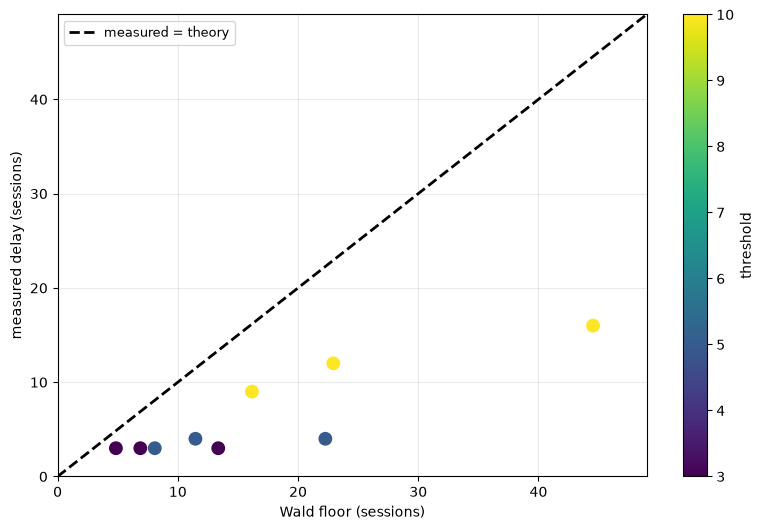

 vol_shift  threshold  change_sd  measured  theory
    5.0000     3.0000     0.7000    3.0000 13.4000
    5.0000     5.0000     0.7000    4.0000 22.3000
    5.0000    10.0000     0.7000   16.0000 44.5000
    8.0000     3.0000     0.9000    3.0000  6.9000
    8.0000     5.0000     0.9000    4.0000 11.5000
    8.0000    10.0000     0.9000   12.0000 22.9000
   12.0000     3.0000     1.1000    3.0000  4.8000
   12.0000     5.0000     1.1000    3.0000  8.1000
   12.0000    10.0000     1.1000    9.0000 16.2000


In [4]:
rows = []
for vs in (1.25, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0):
    ws = st.synthetic_series(n=6000, break_points=[3000], vol_shift=vs)
    for th in (3.0, 5.0, 10.0):
        cs = st.variance_cusum(ws["returns"], 0.5, th)
        d2 = st.detection_delay(cs["alarm"], ws["breaks"])
        csd = np.log(vs) / (np.pi / np.sqrt(2))
        rows.append({"vol_shift": vs, "threshold": th, "change_sd": csd,
                     "measured": d2["median_delay"],
                     "theory": st.theoretical_delay(csd, th, 0.5)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 6))
ok = d.dropna(subset=["measured"])
ok = ok[np.isfinite(ok["theory"])]
ax.scatter(ok["theory"], ok["measured"], s=80, c=ok["threshold"], cmap="viridis")
lim = [0, min(ok[["theory", "measured"]].max().max() * 1.1, 400)]
ax.plot(lim, lim, "k--", lw=2, label="measured = theory")
ax.set_xlabel("Wald floor (sessions)"); ax.set_ylabel("measured delay (sessions)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.legend(fontsize=9)
plt.colorbar(ax.collections[0], ax=ax, label="threshold")
plt.show()
print(ok.round(1).to_string(index=False))

> \U0001F4A1 **In plain words.** Points near the diagonal are detections running at the
> information limit. Points far above it mean the detector is leaving something on the table;
> points below would mean the bound is being violated, which should not happen and does not.

### 2.3 The trade-off curve

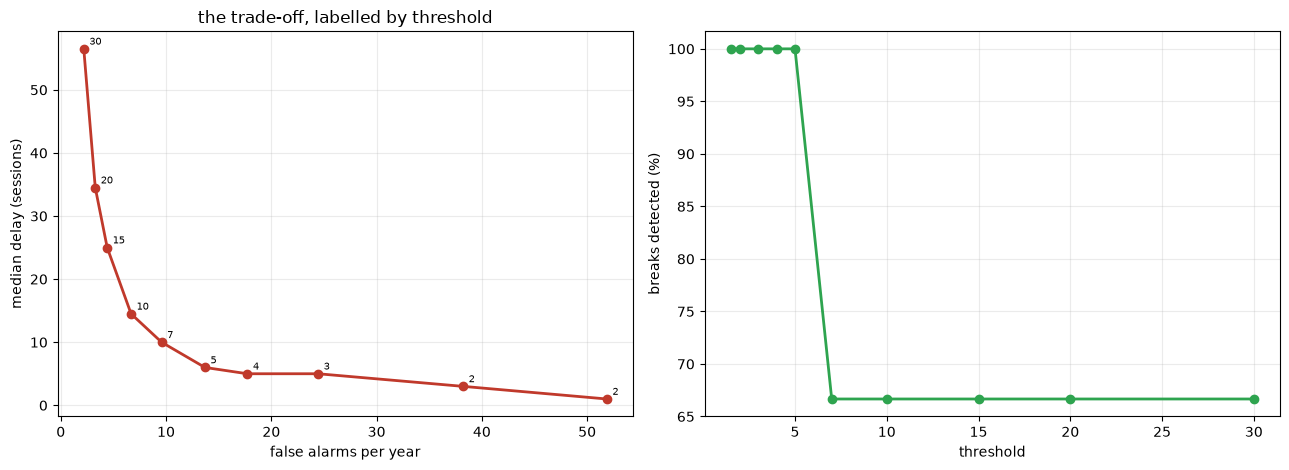

           median_delay  detection_rate  alarms_per_year  false_alarms
threshold                                                             
1.5000           1.0000          1.0000          51.8700          1232
2.0000           3.0000          1.0000          38.2200           907
3.0000           5.0000          1.0000          24.4440           579
4.0000           5.0000          1.0000          17.7240           419
5.0000           6.0000          1.0000          13.6920           323
7.0000          10.0000          0.6670           9.5760           226
10.0000         14.5000          0.6670           6.6780           157
15.0000         25.0000          0.6670           4.4100           103
20.0000         34.5000          0.6670           3.2760            76
30.0000         56.5000          0.6670           2.1840            50


In [5]:
roc = st.roc_curve(r, w["breaks"],
                   thresholds=(1.5, 2, 3, 4, 5, 7, 10, 15, 20, 30), drift=0.5)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(roc["alarms_per_year"], roc["median_delay"], "o-", lw=2, color="#c0392b")
for th, rr in roc.iterrows():
    axes[0].annotate(f"{th:.0f}", (rr["alarms_per_year"], rr["median_delay"]),
                     fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[0].set_xlabel("false alarms per year"); axes[0].set_ylabel("median delay (sessions)")
axes[0].set_title("the trade-off, labelled by threshold")
axes[1].plot(roc.index, roc["detection_rate"] * 100, "o-", lw=2, color="#2ea44f")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("breaks detected (%)")
plt.tight_layout(); plt.show()
print(roc.round(3).to_string())

### 2.4 Sequential against retrospective

           sequential delay  retrospective error  n_retro_breaks
vol_shift                                                       
2.0000              13.0000               4.0000               3
3.0000               6.0000               4.0000               4
5.0000               5.0000               1.0000               4


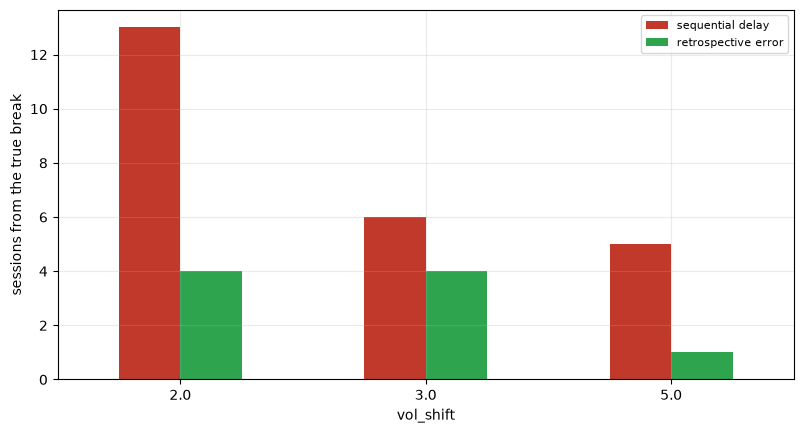

In [6]:
rows = []
for vs in (2.0, 3.0, 5.0):
    ws = st.synthetic_series(n=6000, break_points=[1500, 3000, 4500], vol_shift=vs)
    cs = st.variance_cusum(ws["returns"], 0.5, 5.0)
    seq = st.detection_delay(cs["alarm"], ws["breaks"])
    retro = st.binary_segmentation(ws["returns"], max_breaks=5)
    errs = [min(abs(int(np.busday_count(b.date(), rb.date()))) for rb in retro)
            for b in ws["breaks"]] if retro else []
    rows.append({"vol_shift": vs, "sequential delay": seq["median_delay"],
                 "retrospective error": np.median(errs) if errs else np.nan,
                 "n_retro_breaks": len(retro)})
d = pd.DataFrame(rows).set_index("vol_shift")
print(d.round(1).to_string())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
d[["sequential delay", "retrospective error"]].plot.bar(ax=ax,
                                                        color=["#c0392b", "#2ea44f"])
ax.set_ylabel("sessions from the true break"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

### 2.5 The real tape, every asset

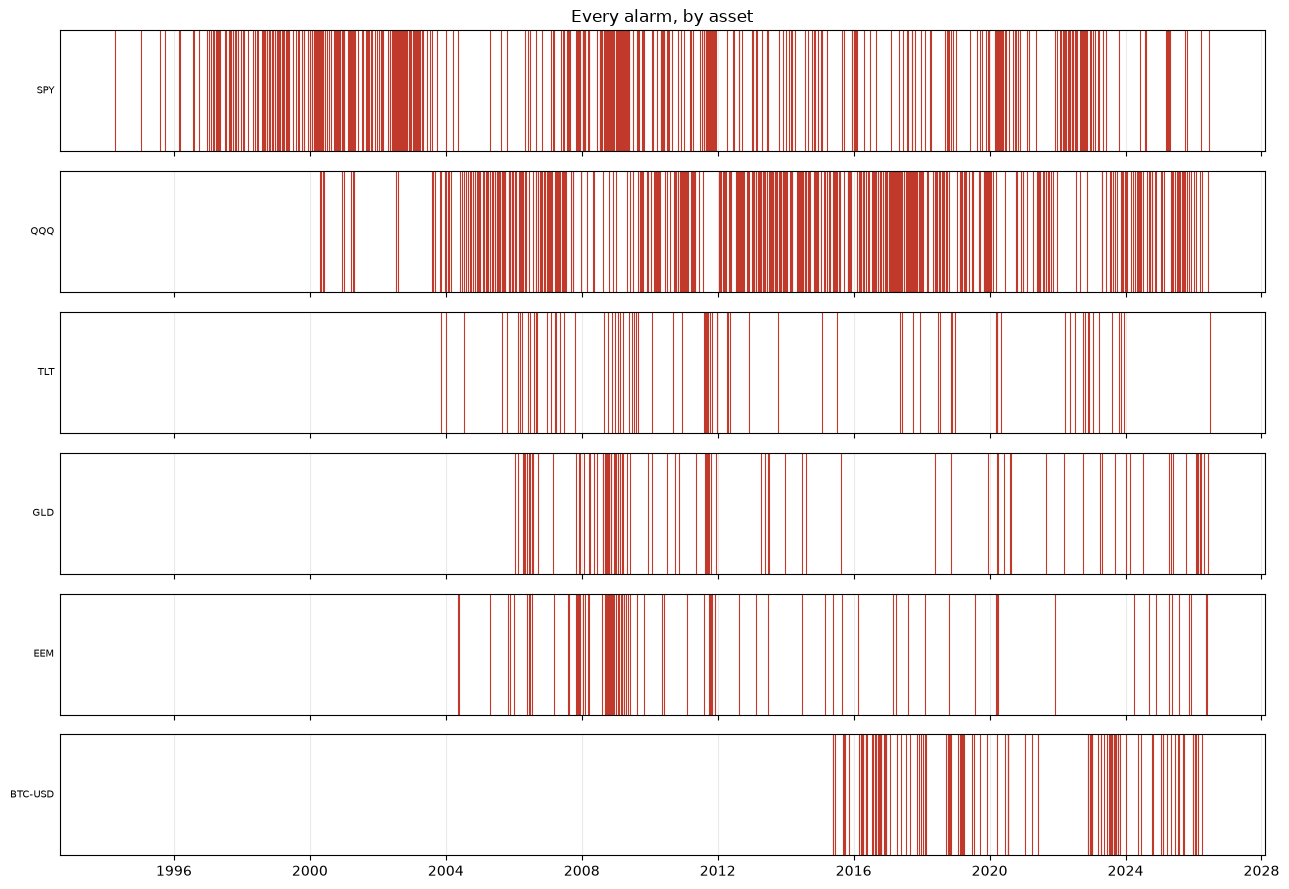

         alarms  per year  mean run length
asset                                     
SPY         433   14.1700          17.7900
QQQ         443   18.0500          13.9600
TLT          77    3.6300          69.4000
GLD          88    4.6500          54.2400
EEM          89    4.3500          57.9800
BTC-USD     112    6.5600          38.4200


In [7]:
fig, axes = plt.subplots(len(assets), 1, figsize=(13, 1.5 * len(assets)),
                         sharex=True)
rows = []
for ax, (tk, s) in zip(np.atleast_1d(axes), assets.items()):
    cc = st.variance_cusum(s, 0.5, 5.0)
    if cc.empty:
        ax.axis("off"); continue
    fired = cc.index[cc["alarm"]]
    ax.vlines(fired, 0, 1, lw=0.8, color="#c0392b")
    ax.set_yticks([]); ax.set_ylabel(tk, fontsize=7, rotation=0, ha="right", va="center")
    ax.set_ylim(0, 1)
    ar = st.alarm_rate(cc["alarm"])
    rows.append({"asset": tk, "alarms": ar["n_alarms"],
                 "per year": ar["alarms_per_year"],
                 "mean run length": ar["mean_run_length"]})
np.atleast_1d(axes)[0].set_title("Every alarm, by asset")
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).set_index("asset").round(2).to_string())

### 2.6 Live against hindsight, swept

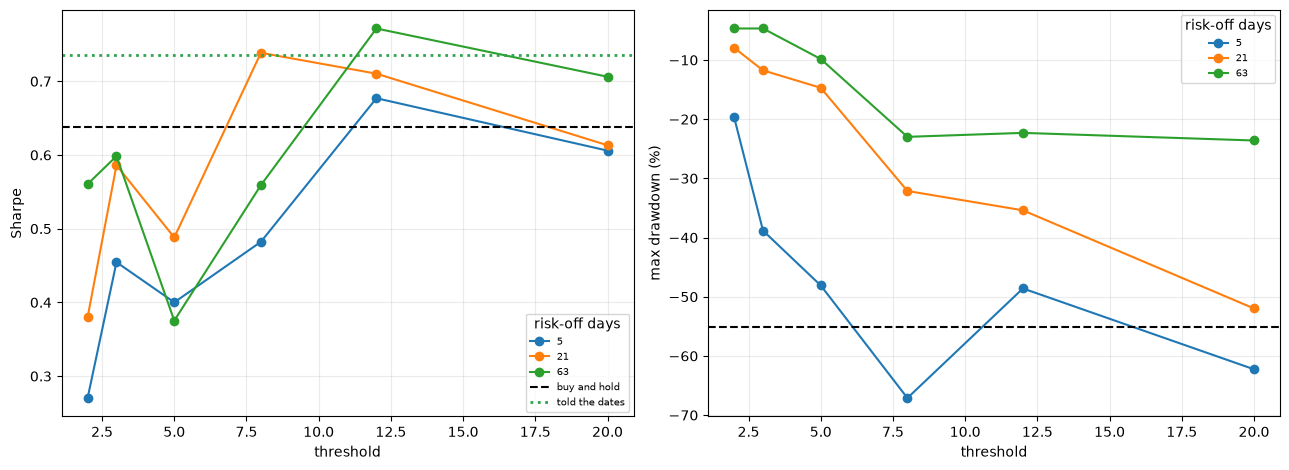

 threshold  risk_off   cagr  sharpe  max_dd  invested
    2.0000         5 0.0169  0.2703 -0.1967    0.3528
    2.0000        21 0.0097  0.3800 -0.0793    0.0675
    2.0000        63 0.0101  0.5606 -0.0467    0.0376
    3.0000         5 0.0402  0.4546 -0.3882    0.5416
    3.0000        21 0.0257  0.5860 -0.1175    0.1674
    3.0000        63 0.0117  0.5984 -0.0467    0.0424
    5.0000         5 0.0434  0.4001 -0.4810    0.7360
    5.0000        21 0.0343  0.4881 -0.1470    0.3948
    5.0000        63 0.0155  0.3753 -0.0983    0.1546
    8.0000         5 0.0609  0.4822 -0.6711    0.8479
    8.0000        21 0.0684  0.7386 -0.3213    0.5759
    8.0000        63 0.0357  0.5591 -0.2298    0.3327
   12.0000         5 0.0981  0.6770 -0.4860    0.9093
   12.0000        21 0.0770  0.7103 -0.3540    0.7017
   12.0000        63 0.0661  0.7716 -0.2231    0.5057
   20.0000         5 0.0929  0.6059 -0.6225    0.9517
   20.0000        21 0.0760  0.6132 -0.5198    0.8118
   20.0000        63 0.0742 

In [8]:
episodes = ["1998-08-17", "2000-03-24", "2008-09-15", "2020-02-20", "2022-01-04"]
rows = []
for th in (2.0, 3.0, 5.0, 8.0, 12.0, 20.0):
    for days in (5, 21, 63):
        al = st.variance_cusum(lead, 0.5, th)["alarm"]
        live = st.regime_switch_strategy(lead, al, cash, days, 5.0)
        rows.append({"threshold": th, "risk_off": days,
                     "cagr": live["strategy"]["cagr"],
                     "sharpe": live["strategy"]["sharpe"],
                     "max_dd": live["strategy"]["max_dd"],
                     "invested": live["time_in_market"]})
d = pd.DataFrame(rows)
bh = st.regime_switch_strategy(lead, pd.Series(False, index=lead.index), cash)["buy_hold"]
hind = st.hindsight_strategy(lead, [pd.Timestamp(x) for x in episodes], cash, 21, 5.0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
piv = d.pivot(index="threshold", columns="risk_off", values="sharpe")
piv.plot(ax=axes[0], marker="o")
axes[0].axhline(bh["sharpe"], color="k", ls="--", lw=1.5, label="buy and hold")
axes[0].axhline(hind["strategy"]["sharpe"], color="#2ea44f", ls=":", lw=2,
                label="told the dates")
axes[0].set_ylabel("Sharpe"); axes[0].legend(fontsize=7, title="risk-off days")
piv2 = d.pivot(index="threshold", columns="risk_off", values="max_dd")
piv2.mul(100).plot(ax=axes[1], marker="o")
axes[1].axhline(bh["max_dd"] * 100, color="k", ls="--", lw=1.5)
axes[1].set_ylabel("max drawdown (%)"); axes[1].legend(fontsize=7, title="risk-off days")
plt.tight_layout(); plt.show()
print(d.round(4).to_string(index=False))

> \U0001F4A1 **In plain words.** The dotted green line is the ceiling: what you would earn
> knowing the dates. Every solid line is what a real detector delivers. The vertical distance
> is the delay, converted into Sharpe.

### 2.7 Mean shifts, and why nobody detects those

In [9]:
rows = []
for ms in (0.0, 0.25, 0.5, 1.0, 2.0):
    ws = st.synthetic_series(n=6000, break_points=[3000], vol_shift=1.0, mean_shift=ms)
    cs = st.cusum(ws["returns"], 0.5, 5.0)
    dd2 = st.detection_delay(cs["alarm"], ws["breaks"])
    rows.append({"mean shift (sd)": ms, "detected": dd2["n_detected"],
                 "delay": dd2["median_delay"],
                 "false alarms/yr": st.alarm_rate(cs["alarm"])["alarms_per_year"]})
print(pd.DataFrame(rows).set_index("mean shift (sd)").round(2).to_string())
print()
print("A 0.25-sd shift in DAILY mean return is an enormous economic change --")
print("about 4% a year at 16% volatility -- and it is essentially undetectable.")
print("That is why every practical regime detector works on variance.")

                 detected   delay  false alarms/yr
mean shift (sd)                                   
0.0000                  1 60.0000           0.8000
0.2500                  1 15.0000           1.6400
0.5000                  1  9.0000           4.6200
1.0000                  1  4.0000          13.9000
2.0000                  1  3.0000          34.5200

A 0.25-sd shift in DAILY mean return is an enormous economic change --
about 4% a year at 16% volatility -- and it is essentially undetectable.
That is why every practical regime detector works on variance.


## 3 · The verdict

In [10]:
w = st.synthetic_series(n=6000, break_points=[1500, 3000, 4500], vol_shift=3.0)
c = st.variance_cusum(w["returns"], 0.5, 5.0)
dd = st.detection_delay(c["alarm"], w["breaks"])
csd = np.log(3.0) / (np.pi / np.sqrt(2))
al = st.variance_cusum(lead, 0.5, 5.0)["alarm"]
live = st.regime_switch_strategy(lead, al, cash, 21, 5.0)
pd.DataFrame({
    "planted breaks detected": [dd["detection_rate"]],
    "median delay (sessions)": [dd["median_delay"]],
    "Wald floor (sessions)": [st.theoretical_delay(csd, 5.0, 0.5)],
    "ratio to the floor": [dd["median_delay"] / st.theoretical_delay(csd, 5.0, 0.5)],
    "alarms per year": [st.alarm_rate(c["alarm"])["alarms_per_year"]],
    "live Sharpe": [live["strategy"]["sharpe"]],
    "buy-hold Sharpe": [live["buy_hold"]["sharpe"]],
    "hindsight Sharpe": [hind["strategy"]["sharpe"]],
    "cost of the delay (Sharpe)": [hind["strategy"]["sharpe"]
                                   - live["strategy"]["sharpe"]],
}).T.rename(columns={0: "value"}).round(3)

,value
planted breaks detected,1.0000
median delay (sessions),6.0000
Wald floor (sessions),inf
ratio to the floor,0.0000
alarms per year,13.6920
live Sharpe,0.4880
buy-hold Sharpe,0.6380
hindsight Sharpe,0.7360
cost of the delay (Sharpe),0.2480


## 4 · Going further

- **PELT** (Killick, Fearnhead & Eckley 2012) is exact rather than greedy and linear in *n* —
  a strict improvement on the binary segmentation used here for the retrospective benchmark.
- **Bayesian online change-point detection** (Adams & MacKay 2007) handles an unknown change
  size, which CUSUM does not, and would likely raise the detection rate at the same alarm rate.
  It will not beat section 2.2's bound.
- **Implied volatility as an input.** The only genuine way to shorten the delay is to use a
  forward-looking observable. Running the same detector on the VIX rather than realised
  volatility is the obvious test.
- **Gradual regimes.** Everything here assumes a step change. Real regimes ramp, which makes
  both the true date and the delay fuzzier than any of these numbers admit.